In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('data.csv')

data.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [4]:
data['DateTime'] = pd.to_datetime(data['DateTime'])
data['DateTime'] = pd.to_datetime(data['DateTime'])
data['date'] = data['DateTime'].dt.date
data['time'] = data['DateTime'].dt.time

data.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,date,time
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,2017-01-01,00:00:00
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,2017-01-01,00:10:00
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,2017-01-01,00:20:00
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,2017-01-01,00:30:00
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,2017-01-01,00:40:00


In [5]:
data['hour'] = data['DateTime'].dt.hour

data.head(10)

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,date,time,hour
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,2017-01-01,00:00:00,0
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,2017-01-01,00:10:00,0
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,2017-01-01,00:20:00,0
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,2017-01-01,00:30:00,0
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,2017-01-01,00:40:00,0
5,2017-01-01 00:50:00,5.853,76.9,0.081,0.059,0.108,26624.81013,17416.41337,18130.12048,2017-01-01,00:50:00,0
6,2017-01-01 01:00:00,5.641,77.7,0.080,0.048,0.096,25998.98734,16993.31307,17945.06024,2017-01-01,01:00:00,1
7,2017-01-01 01:10:00,5.496,78.2,0.085,0.055,0.093,25446.07595,16661.39818,17459.27711,2017-01-01,01:10:00,1
8,2017-01-01 01:20:00,5.678,78.1,0.081,0.066,0.141,24777.72152,16227.35562,17025.54217,2017-01-01,01:20:00,1
9,2017-01-01 01:30:00,5.491,77.3,0.082,0.062,0.111,24279.49367,15939.20973,16794.21687,2017-01-01,01:30:00,1


In [6]:
print(data.shape)

feature_data = data[['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'hour']]
target_data = data[['Zone 1 Power Consumption']]

print(feature_data.shape)

(52416, 12)
(52416, 6)


In [7]:
    split_point = int(len(feature_data) * 0.75)

    # Train 75%
    train_features = feature_data[:split_point]
    train_target = target_data[:split_point]

    # Test 25%
    test_features = feature_data[split_point:]
    test_target = target_data[split_point:]

In [8]:
def sliding_window(feature_data, target_data, window_size=144, pred_horizon=24, stride=6):

    X = []
    y = []

    position = window_size

    while position + pred_horizon <= len(feature_data):
        window = feature_data[position - window_size : position]

        targets = target_data[position : position + pred_horizon].values.flatten()

        flattened = window.values.flatten()

        X.append(flattened)
        y.append(targets)

        position = position + stride

    return np.array(X), np.array(y)


In [9]:
X_train, y_train = sliding_window(train_features, train_target)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

X_test, y_test = sliding_window(test_features, test_target)
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (6525, 864), y_train: (6525, 24)
X_test: (2157, 864), y_test: (2157, 24)


In [10]:
rmses = []
mapes = []

## LightLGBM regressor

In [11]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

base_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbose=1,
)

model = MultiOutputRegressor(base_model)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 172896
[LightGBM] [Info] Number of data points in the train set: 6525, number of used features: 864
[LightGBM] [Info] Start training from score 32989.558173
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,estimator,"LGBMRegressor...42, verbose=1)"
,n_jobs,None
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [12]:
y_pred = model.predict(X_test)

C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packag

In [13]:
print(f"y_pred: {y_pred.shape}")
print(f"y_test: {y_test.shape}")

y_pred: (2157, 24)
y_test: (2157, 24)


In [14]:
print(f"\nFirst prediction (24 steps): {y_pred[0]}")
print(f"First actual (24 steps): {y_test[0]}")


First prediction (24 steps): [29506.07204617 29847.81860309 28821.08544063 29004.87209509
 28510.71618632 28209.41108772 27802.07697637 27896.3744577
 27633.00394729 27720.60522203 27363.08318926 26016.69067324
 26637.22724091 25947.73569515 26370.98797587 26055.73734595
 25659.88512236 25232.99974743 25425.47362235 25510.19643239
 25157.92634086 24791.18285599 25544.89109143 26007.21033326]
First actual (24 steps): [30583.45733 29827.22101 29253.74179 28850.41575 28573.1291  28119.38731
 27835.79869 27495.49234 27199.29978 26890.50328 26676.23632 26581.70678
 26348.53392 26140.56893 26348.53392 26146.8709  26134.26696 26046.03939
 25989.32166 25812.86652 25856.98031 25806.56455 25901.09409 25989.32166]


In [15]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmses.append(rmse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mapes.append(mape)

print(f"RMSE: {rmse}, MAPE: {mape}")

RMSE: 2697.0470397442555, MAPE: 7.231104396988483


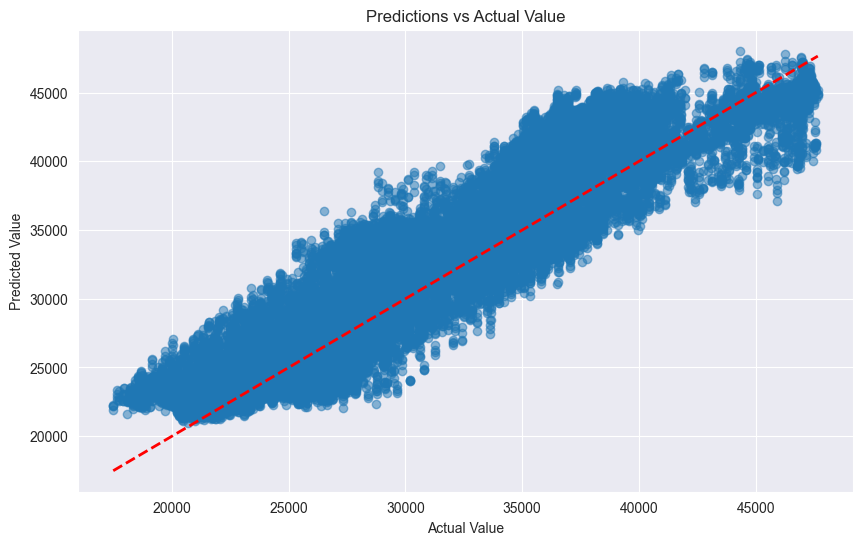

In [16]:
# Visualization

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title("Predictions vs Actual Value")
plt.grid(True)
plt.show()

## XGBOOST

In [17]:
from xgboost import XGBRegressor

xgboost_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
)

model = MultiOutputRegressor(xgboost_model)

model.fit(X_train, y_train)


,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None


In [18]:
y_pred = model.predict(X_test)

In [19]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmses.append(rmse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mapes.append(mape)

print(f"RMSE: {rmse}, MAPE: {mape}")

RMSE: 2663.078331494727, MAPE: 7.1533852346973905


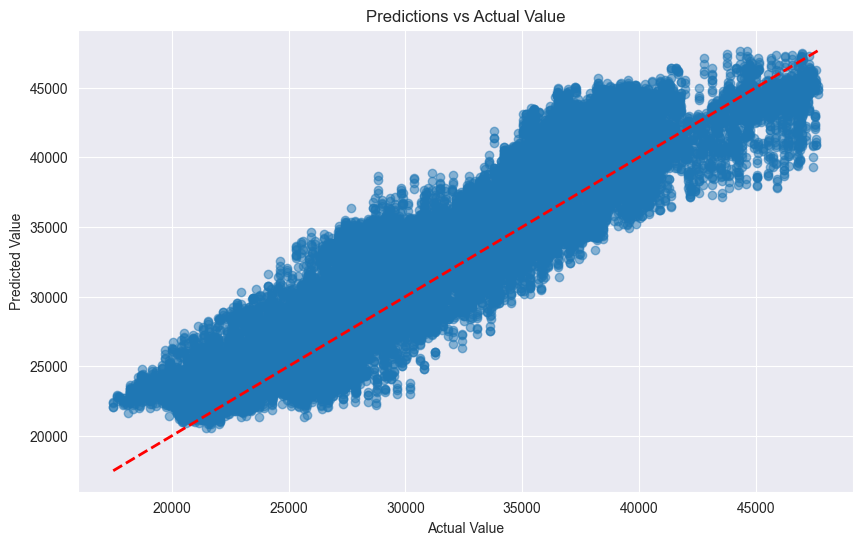

In [20]:
# Visualization

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title("Predictions vs Actual Value")
plt.grid(True)
plt.show()

## XGBOOST VS LIGHTGBM

(0.0, 7.954214836687332)

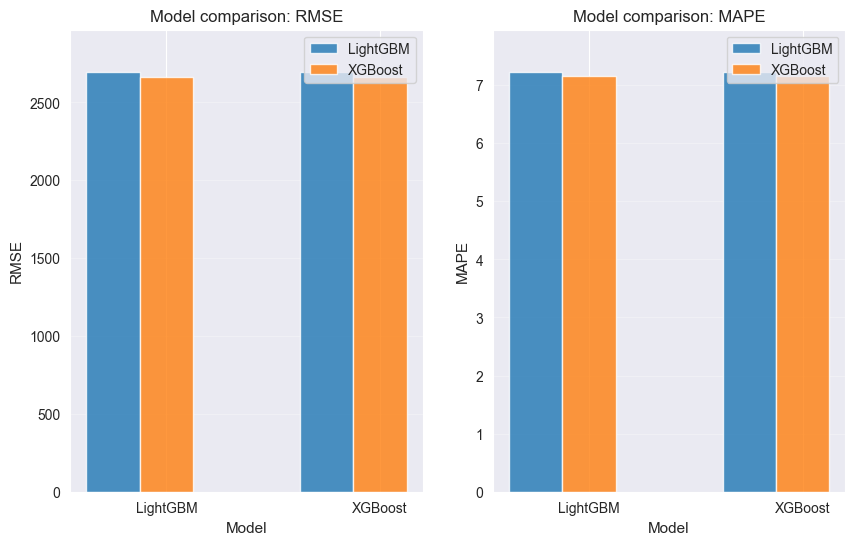

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

model_names = ['LightGBM', 'XGBoost']

x = np.arange(len(model_names))
width = 0.25

# Plot 1: RMSE
axes[0].bar(x - width, rmses[0], width, label=model_names[0], alpha=0.8)
axes[0].bar(x, rmses[1], width, label=model_names[1], alpha=0.8)
axes[0].set_xlabel('Model', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('Model comparison: RMSE', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, max(rmses) * 1.1)

# Plot 2: MAPE
axes[1].bar(x - width, mapes[0], width, label=model_names[0], alpha=0.8)
axes[1].bar(x, mapes[1], width, label=model_names[1], alpha=0.8)
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('MAPE', fontsize=11)
axes[1].set_title('Model comparison: MAPE', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, max(mapes) * 1.1)



XGBoost is just slightly better